In [6]:
!python -m pip install transformers darts scikit-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.8/51.8 kB 4.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.5/160.5 kB 31.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 884.7/884.7 kB 40.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 48.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 43.3 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 540.6/540.6 kB 47.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 133.4/133.4 kB 60.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 45.3 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 22.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.7/101.7 kB 49.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 51.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 297.1/297.1 MB 20.7 MB/

In [7]:
import numpy as np
import torch
from darts.datasets import AirPassengersDataset
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset
from transformers import PatchTSMixerConfig, PatchTSMixerForTimeSeriesClassification
import torch.optim as optim
from sklearn.metrics import accuracy_score

# Load the dataset
series = AirPassengersDataset().load()

# Convert the series to a pandas DataFrame
df = series.pd_dataframe()

# Define window size and patch size
window_size = 4  # e.g., use 12 months as a window
patch_size = 1  # Each patch will be 1 time step

# Generate windows of data
# Define window size
window_size = 16  # Use 16 months as a window

# Generate windows of data
def create_windows(data, window_size):
    X = []
    y = []
    for i in range(len(data) - window_size):
        window = data[i:i + window_size]
        X.append(window)
        y.append(data[i + window_size])  # Use the next value as the label for the window

    return np.array(X), np.array(y)

X, y = create_windows(df['#Passengers'].values, window_size)

# Generate labels based on a threshold (e.g., classify if number of passengers is above or below the median of the next value in the window)
threshold = np.median(y)
labels = np.array([1 if val > threshold else 0 for val in y])

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, labels, test_size=0.2, random_state=42)

# Convert to PyTorch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32).unsqueeze(1)  # Add an extra dimension for the channel
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32).unsqueeze(1)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

# Create DataLoader
train_dataset = TensorDataset(X_train_tensor.transpose(1,2), y_train_tensor)
test_dataset = TensorDataset(X_test_tensor.transpose(1,2), y_test_tensor) # batch, seq, var

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)


In [70]:
from transformers import PatchTSMixerForPretraining,PatchTSMixerConfig

config = PatchTSMixerConfig(
    num_channels=1,  # Number of features (or channels in this context)
    patch_length=2,  # Patch size for time series, which should match the window size
    context_length=16,  # Number of patches
    # num_labels=2,  # Number of labels (binary classification)
    patch_stride=1
)
model = PatchTSMixerForPretraining(config)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)


PatchTSMixerForPretraining(
  (model): PatchTSMixerModel(
    (encoder): PatchTSMixerEncoder(
      (patcher): Linear(in_features=2, out_features=8, bias=True)
      (mlp_mixer_encoder): PatchTSMixerBlock(
        (mixers): ModuleList(
          (0-2): 3 x PatchTSMixerLayer(
            (patch_mixer): PatchMixerBlock(
              (norm): PatchTSMixerNormLayer(
                (norm): LayerNorm((8,), eps=1e-05, elementwise_affine=True)
              )
              (mlp): PatchTSMixerMLP(
                (fc1): Linear(in_features=15, out_features=30, bias=True)
                (dropout1): Dropout(p=0.2, inplace=False)
                (fc2): Linear(in_features=30, out_features=15, bias=True)
                (dropout2): Dropout(p=0.2, inplace=False)
              )
              (gating_block): PatchTSMixerGatedAttention(
                (attn_layer): Linear(in_features=15, out_features=15, bias=True)
                (attn_softmax): Softmax(dim=-1)
              )
            )
        

In [72]:
# pretraining
import torch.optim as optim
import torch.nn.functional as F

# Optimizer and loss function
optimizer = optim.Adam(model.parameters(), lr=5e-4)

num_epochs = 100

for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    for batch in train_loader:
        inputs, labels = batch
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs, inputs.clone())
        loss = outputs.loss
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    avg_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch + 1}/{num_epochs}, Loss: {avg_loss:.4f}")

print("Training completed.")
model.save_pretrained("model.pth")

Epoch 1/100, Loss: 0.0044
Epoch 2/100, Loss: 0.0041
Epoch 3/100, Loss: 0.0042
Epoch 4/100, Loss: 0.0039
Epoch 5/100, Loss: 0.0039
Epoch 6/100, Loss: 0.0043
Epoch 7/100, Loss: 0.0039
Epoch 8/100, Loss: 0.0038
Epoch 9/100, Loss: 0.0038
Epoch 10/100, Loss: 0.0039
Epoch 11/100, Loss: 0.0038
Epoch 12/100, Loss: 0.0038
Epoch 13/100, Loss: 0.0037
Epoch 14/100, Loss: 0.0039
Epoch 15/100, Loss: 0.0038
Epoch 16/100, Loss: 0.0039
Epoch 17/100, Loss: 0.0037
Epoch 18/100, Loss: 0.0038
Epoch 19/100, Loss: 0.0037
Epoch 20/100, Loss: 0.0036
Epoch 21/100, Loss: 0.0036
Epoch 22/100, Loss: 0.0038
Epoch 23/100, Loss: 0.0038
Epoch 24/100, Loss: 0.0036
Epoch 25/100, Loss: 0.0036
Epoch 26/100, Loss: 0.0037
Epoch 27/100, Loss: 0.0037
Epoch 28/100, Loss: 0.0038
Epoch 29/100, Loss: 0.0035
Epoch 30/100, Loss: 0.0038
Epoch 31/100, Loss: 0.0036
Epoch 32/100, Loss: 0.0035
Epoch 33/100, Loss: 0.0037
Epoch 34/100, Loss: 0.0036
Epoch 35/100, Loss: 0.0035
Epoch 36/100, Loss: 0.0035
Epoch 37/100, Loss: 0.0035
Epoch 38/1

Configuration saved in model.pth/config.json
Model weights saved in model.pth/model.safetensors


Epoch 99/100, Loss: 0.0020
Epoch 100/100, Loss: 0.0019
Training completed.


Some weights of PatchTSMixerForTimeSeriesClassification were not initialized from the model checkpoint at model.pth and are newly initialized: ['head.projection.bias', 'head.projection.weight', 'inject_scale.inverse_trans_compression.bias', 'inject_scale.inverse_trans_compression.weight', 'inject_scale.inverse_trans_expansion.bias', 'inject_scale.inverse_trans_expansion.weight', 'inject_scale.map_scale_compression.bias', 'inject_scale.map_scale_compression.weight', 'inject_scale.map_scale_expansion.bias', 'inject_scale.map_scale_expansion.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


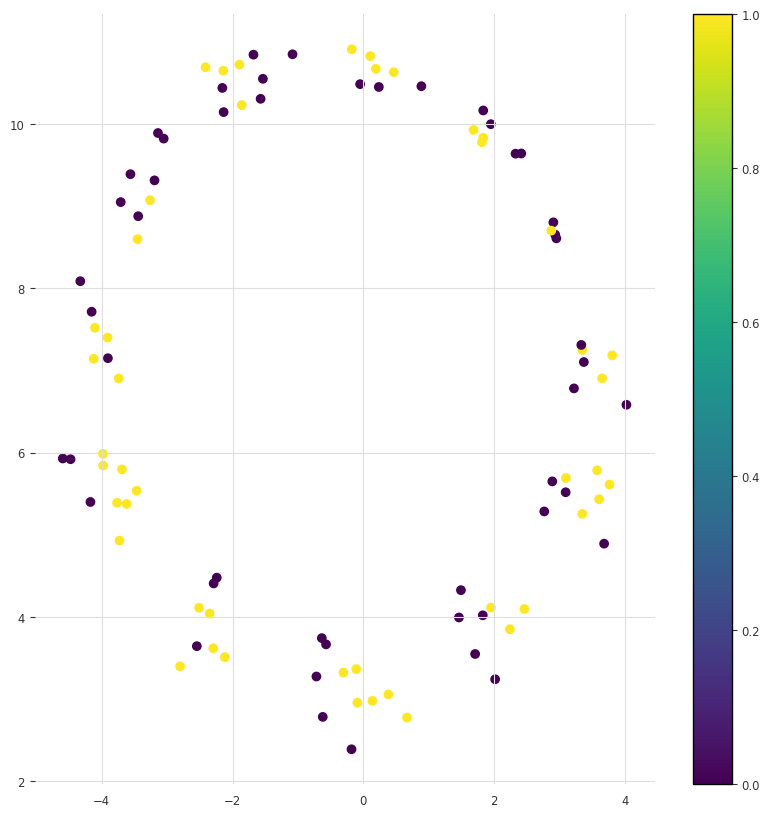

In [8]:
from transformers import PatchTSMixerConfig, PatchTSMixerForTimeSeriesClassification

# Define the model configuration
config = PatchTSMixerConfig(
    num_channels=1,  # Number of features (or channels in this context)
    patch_length=2,  # Patch size for time series, which should match the window size
    context_length=16,  # Number of patches
    num_labels=2,  # Number of labels (binary classification)
    patch_stride=1
)

# Initialize the model
model = PatchTSMixerForTimeSeriesClassification.from_pretrained("model.pth", config=config)
# model = PatchTSMixerForTimeSeriesClassification(config)
for param in model.model.parameters():
    param.requires_grad = False

# Move model to GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

# plot tsne of the model
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# Get the embeddings
embeddings = []
labels = []
model.eval()
with torch.no_grad():
    for batch in train_loader:
        inputs, labels_batch = batch
        inputs, labels_batch = inputs.to(device), labels_batch.to(device)
        outputs = model(inputs, labels_batch)
        embeddings.append(outputs.last_hidden_state.view(8, -1))  # Use the last hidden state as the embedding
        labels.append(labels_batch)
embeddings = torch.cat(embeddings[:-1]).cpu().numpy()
labels = torch.cat(labels).cpu().numpy()

# Perform t-SNE
tsne = TSNE(n_components=2)
embeddings_tsne = tsne.fit_transform(embeddings)

# Plot the t-SNE embeddings
plt.figure(figsize=(10, 10))
plt.scatter(embeddings_tsne[:, 0], embeddings_tsne[:, 1], c=labels[:-6], cmap='viridis')
plt.colorbar()
plt.show()




In [109]:
import torch.optim as optim
import torch.nn.functional as F

# Optimizer and loss function
optimizer = optim.Adam(model.parameters(), lr=5e-4)

num_epochs = 30

for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    for batch in train_loader:
        inputs, labels = batch
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs, labels)
        loss = outputs.loss
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    avg_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch + 1}/{num_epochs}, Loss: {avg_loss:.4f}")

print("Training completed.")


Epoch 1/30, Loss: 3.2631
Epoch 2/30, Loss: 2.0464
Epoch 3/30, Loss: 1.3052
Epoch 4/30, Loss: 1.1027
Epoch 5/30, Loss: 0.9384
Epoch 6/30, Loss: 0.8855
Epoch 7/30, Loss: 0.7210
Epoch 8/30, Loss: 0.7363
Epoch 9/30, Loss: 0.7409
Epoch 10/30, Loss: 0.6558
Epoch 11/30, Loss: 0.7193
Epoch 12/30, Loss: 0.6551
Epoch 13/30, Loss: 0.7336
Epoch 14/30, Loss: 0.6454
Epoch 15/30, Loss: 0.6578
Epoch 16/30, Loss: 0.5622
Epoch 17/30, Loss: 0.6342
Epoch 18/30, Loss: 0.6160
Epoch 19/30, Loss: 0.5782
Epoch 20/30, Loss: 0.5567
Epoch 21/30, Loss: 0.6405
Epoch 22/30, Loss: 0.5785
Epoch 23/30, Loss: 0.5687
Epoch 24/30, Loss: 0.5626
Epoch 25/30, Loss: 0.5511
Epoch 26/30, Loss: 0.5377
Epoch 27/30, Loss: 0.5130
Epoch 28/30, Loss: 0.5380
Epoch 29/30, Loss: 0.5553
Epoch 30/30, Loss: 0.5030
Training completed.


In [110]:
from sklearn.metrics import accuracy_score

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for batch in test_loader:
        inputs, labels = batch
        inputs, labels = inputs.to(device), labels.to(device)
        
        outputs = model(inputs, labels)
        loss = outputs.loss
        preds = outputs.prediction_outputs
        _, preds = torch.max(preds, 1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

accuracy = accuracy_score(all_labels, all_preds)
print(f"Test Accuracy: {accuracy:.4f}")


Test Accuracy: 0.8846
